# K-Means Clustering

### Objectives

- Load RFM Dataset
- Handle Outliers
- Scale Features
- Find Optimal K
- Train KMeans
- Evaluate Clusters
- PCA Visualization
- Save Model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import joblib

pd.set_option("display.max_columns",None)

In [2]:
rfm = pd.read_csv("/content/sample_data/rfm_data.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [3]:
print(rfm.shape)

rfm.info()

(4338, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   int64  
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


In [4]:
X = rfm[["Recency","Frequency","Monetary"]]

X.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


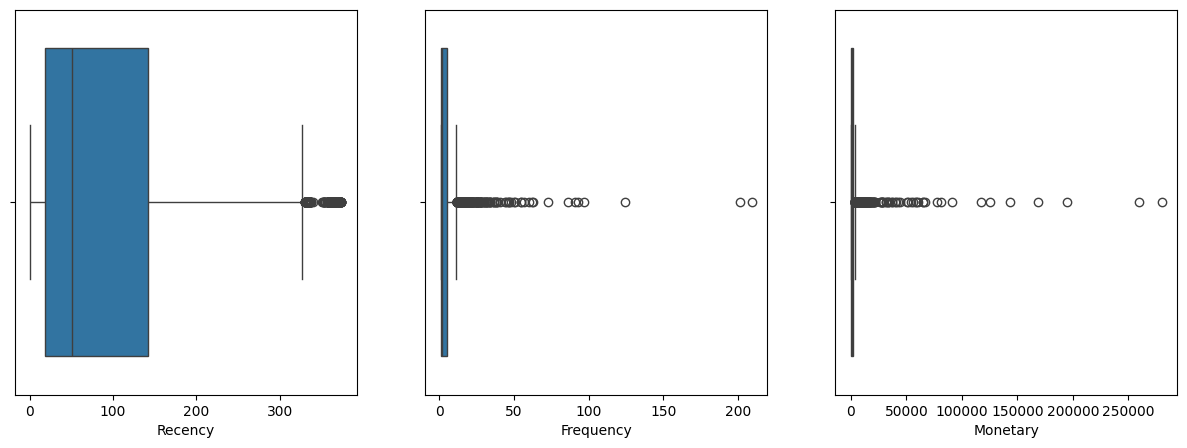

In [5]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x=X["Recency"])

plt.subplot(1,3,2)
sns.boxplot(x=X["Frequency"])

plt.subplot(1,3,3)
sns.boxplot(x=X["Monetary"])

plt.show()

In [6]:
def cap_outliers(df,col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] > upper,upper,np.where(df[col] < lower, lower, df[col]))
    return df

In [7]:
for col in ["Recency","Frequency","Monetary"]:
    X = cap_outliers(X,col)

X.head()

/tmp/ipykernel_256/3720387617.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] > upper,upper,np.where(df[col] < lower, lower, df[col]))
/tmp/ipykernel_256/3720387617.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.where(df[col] > upper,upper,np.where(df[col] < lower, lower, df[col]))
/tmp/ipykernel_256/3720387617.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

,Recency,Frequency,Monetary
0,326.0,1.0,3691.77
1,2.0,7.0,3691.77
2,75.0,4.0,1797.24
3,19.0,1.0,1757.55
4,310.0,1.0,334.40


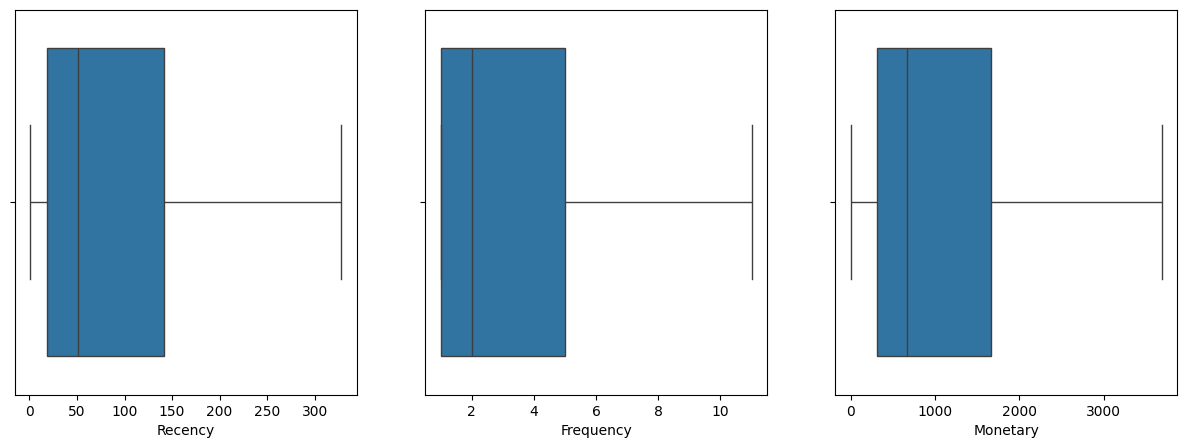

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x=X["Recency"])

plt.subplot(1,3,2)
sns.boxplot(x=X["Frequency"])

plt.subplot(1,3,3)
sns.boxplot(x=X["Monetary"])

plt.show()

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 2.41338159, -0.81803497,  2.20884284],
       [-0.92035154,  1.15580523,  2.20884284],
       [-0.16923265,  0.16888513,  0.55660564],
       [-0.74543344, -0.81803497,  0.52199163],
       [ 2.24875279, -0.81803497, -0.7191507 ]])

In [10]:
inertia = []

for k in range(2,11):

    model = KMeans(n_clusters=k,random_state=42,n_init=10)

    model.fit(X_scaled)

    inertia.append(model.inertia_)

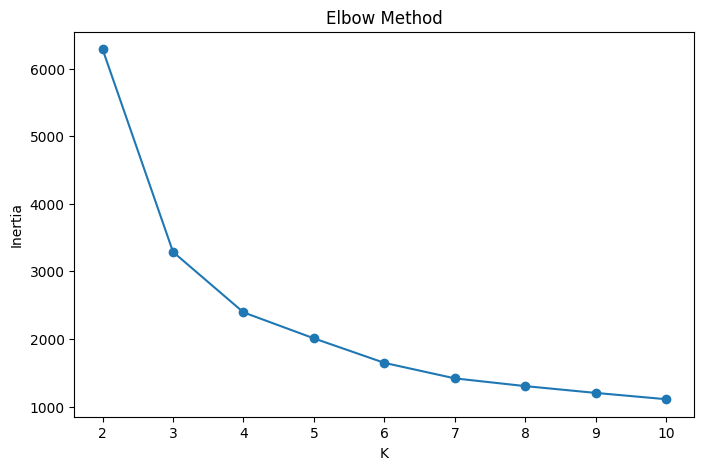

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),inertia,marker="o")

plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [12]:
scores = []

for k in range(2,11):

    model = KMeans(n_clusters=k,random_state=42,n_init=10)

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled,labels)

    scores.append(score)

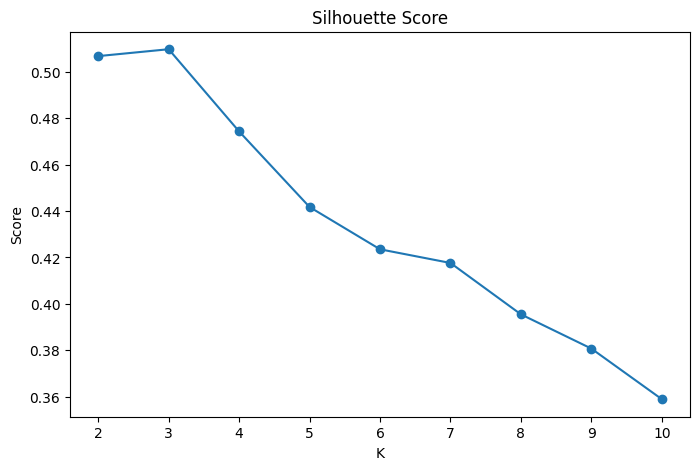

In [13]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),scores,marker="o")

plt.title("Silhouette Score")

plt.xlabel("K")

plt.ylabel("Score")

plt.show()

In [14]:
for k,score in zip(range(2,11),scores):
    print( f"K = {k} | Silhouette = {score:.4f}")

K = 2 | Silhouette = 0.5067
K = 3 | Silhouette = 0.5097
K = 4 | Silhouette = 0.4743
K = 5 | Silhouette = 0.4417
K = 6 | Silhouette = 0.4235
K = 7 | Silhouette = 0.4176
K = 8 | Silhouette = 0.3955
K = 9 | Silhouette = 0.3807
K = 10 | Silhouette = 0.3589


In [25]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

clusters = kmeans.fit_predict(X_scaled)

In [26]:
rfm["Cluster"] = clusters
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,1
1,12347,2,7,4310.00,2
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


In [27]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,2328
1,1046
2,964


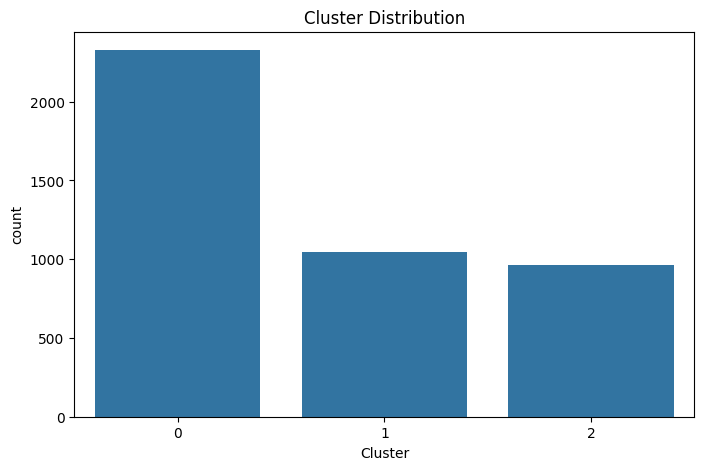

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(data=rfm,x="Cluster")

plt.title("Cluster Distribution")
plt.show()

In [29]:
pca = PCA( n_components=2,random_state=42)

X_pca = pca.fit_transform(X_scaled)

In [30]:
pca_df = pd.DataFrame(X_pca,columns=["PC1","PC2"])

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.272884,2.715302,1
1,2.527707,0.340135,2
2,0.530485,0.105844,0
3,0.154812,-0.699648,0
4,-2.010766,1.482873,1


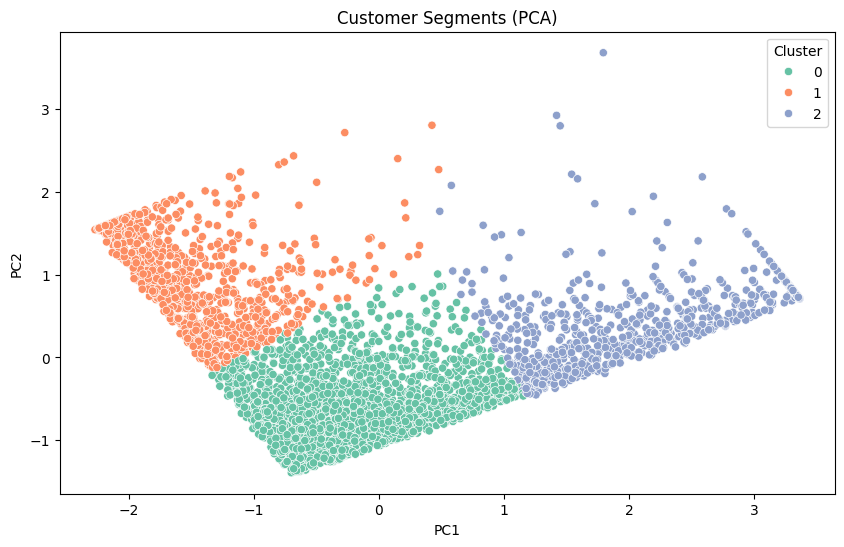

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="Set2")

plt.title("Customer Segments (PCA)")
plt.show()

In [32]:
cluster_profile = (rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean().round(2))

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,49.11,2.46,726.14
1,249.64,1.47,498.16
2,26.94,11.69,6924.97


In [33]:
rfm.to_csv("/content/sample_data/clustered_data.csv",
    index=False
)

print("Clustered Data Saved")

Clustered Data Saved


In [34]:
joblib.dump(scaler,"/content/sample_data/scaler.pkl")

joblib.dump(kmeans,"/content/sample_data/kmeans.pkl")

joblib.dump(pca,"/content/sample_data/pca.pkl")

print("Models Saved Successfully")

Models Saved Successfully


In [36]:
final_score = silhouette_score(X_scaled,clusters)

print(f"Final Silhouette Score: {final_score:.4f}")

Final Silhouette Score: 0.5097
